# Image Annotation for Image Recognition and Segmentation

This notebook prepares a sample of images for annotation in Label Studio and produces the labeled dataset used to train the image-type classifier and segmentation models in notebook 06.

Images are annotated with both a **type label** and a **brush mask** over the color region. The original design called for five label classes:

- `swatch` — flat color swatch, no packaging; background thresholding is sufficient for extraction
- `bullet` — classic lipstick tube with exposed bullet tip
- `liquid` — liquid lipstick, stain, or gloss with doe-foot wand
- `closed` — container is closed but has a **transparent window through which the color is visible**; a mask is drawn over that window
- `color_not_shown` — container is fully sealed with no color visible; extraction is not possible

Round 3 (below) surfaced two packaging patterns that didn't fit any of these and were added as new classes:

- `pencil` — pen/crayon-style applicator (twist-up or felt-tip), distinct from a bullet's tube or a liquid's doe-foot wand
- `lips` — the image shows the product applied to a model's lips rather than the product, its container, or a swatch

**Why `closed` and `color_not_shown` are separate classes:** Both involve packaging without an exposed product, but they are fundamentally different extraction cases. `closed` images have a recoverable color (visible through the container) and route to a dedicated segmenter. `color_not_shown` images have nothing to extract and must be explicitly declined; otherwise the pipeline would invent a color from sealed packaging. A first iteration of the classifier used a single `other` label for both, which collapsed this distinction and caused `color_not_shown` images to be misrouted to a segmenter. Splitting them into two classes is the fix.

**Annotation rounds:**
- Round 1: 208 images annotated (222 sampled, 14 missing from disk). Only 6 `closed` images — too few to train on.
- Round 2 (active learning): Rather than annotating at random, the 6 confirmed `closed` images from Round 1 were used to identify their product lines (Chanel Le Rouge Duo, BareMinerals Gen Nude Matte, Juice Beauty Phytopigments, Revlon Ultra HD Lip Mousse). Other shades from those same lines were targeted for annotation: same product = same packaging = high-confidence `closed` candidates, without requiring visual inspection of every image. 40 images were sampled proportionally across the 4 lines and annotated, bringing `closed` to 34 labeled examples.
- Round 3 (general oversampling): 54 additional images sampled; 49 annotated (5 left incomplete in Label Studio and excluded here). Split `bullet` (25), `liquid` (12), `closed` (5), and two new classes — `pencil` (4) and `lips` (3) — that didn't fit the original taxonomy. Brings the combined set to 297 labeled images.

**Steps:**
1. Explore product name keywords to understand type distribution in the annotation sample
2. Copy the 208 annotation sample images to `data/img/annotation_sample/` for Label Studio
3. Launch Label Studio and annotate: see Annotation Guidelines in this notebook
4. Load annotations and export to `data/processed/annotations.csv`
5. Oversample `closed` containers via product-line matching and run a second annotation round
6. Classifier and segmentation training → notebook 06

**Inputs:** `data/processed/annotation_sample.csv`, `data/processed/products_with_images.csv`, `data/img/original_clean/`, `data/processed/annotations_label_studio.json`, `data/processed/annotations_label_studio_closed_addition.json`, `data/processed/project-4-at-2026-07-24-22-36-c698fb5f.json`

**Outputs:** `data/img/annotation_sample/` (208 images), `data/img/annotation_sample_closed/` (40 images), `data/processed/annotations.csv`, `data/processed/annotations_r2.csv`, `data/processed/annotations_combined.csv`

# Setup

In [3]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE   = os.path.abspath('../data')
CLEAN  = os.path.join(BASE, 'img', 'original_clean')
ANNOT  = os.path.join(BASE, 'img', 'annotation_sample')
DATA   = os.path.join(BASE, 'processed')

# Exploring Product Types in the Annotation Sample

Product names in the metadata contain keywords that hint at visual format: "liquid", "stain", "velvet", etc. signal a wand/tube presentation rather than a classic bullet. This is not a ground truth label, but it gives a useful prior for understanding what annotators will encounter.

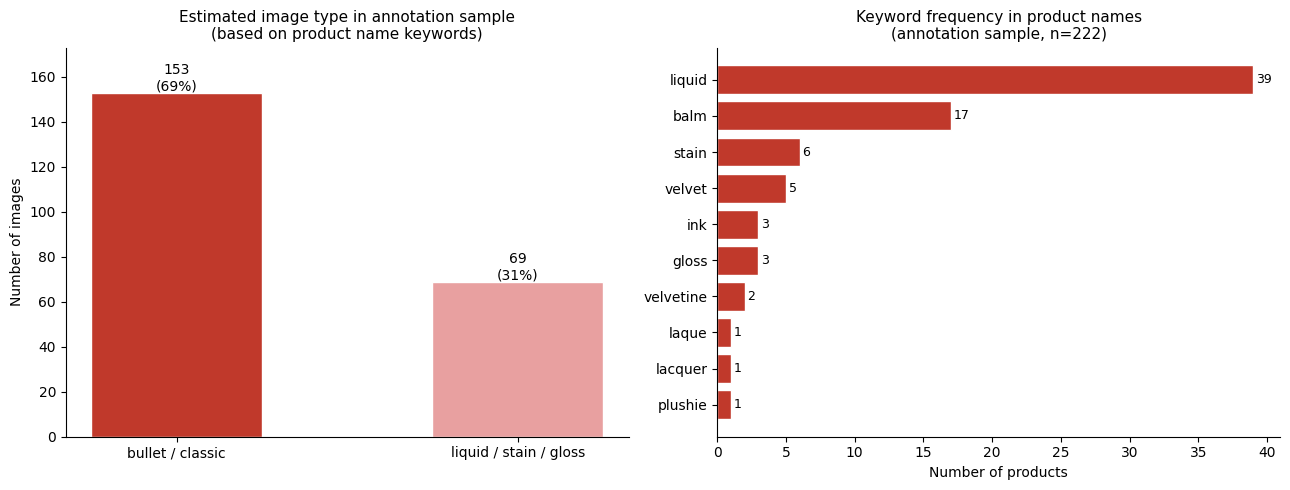


Total in sample: 222
product_type
bullet / classic          153
liquid / stain / gloss     69


In [7]:
sample   = pd.read_csv(f'{DATA}/annotation_sample.csv')
products = pd.read_csv(f'{DATA}/products_with_images.csv')
df       = sample.merge(products[['id', 'product']], on='id', how='left')

LIQUID_KEYWORDS = ['liquid', 'velvet', 'velvetine', 'plushie', 'fluid',
                   'stain', 'lacquer', 'laque', 'gloss', 'balm', 'ink', 'laquer']

def keyword_type(product_name):
    name = str(product_name).lower()
    return 'liquid / stain / gloss' if any(k in name for k in LIQUID_KEYWORDS) else 'bullet / classic'

df['product_type'] = df['product'].apply(keyword_type)

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: high-level split
counts = df['product_type'].value_counts()
colors = ['#c0392b', '#e8a0a0']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Estimated image type in annotation sample\n(based on product name keywords)', fontsize=11)
ax1.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax1.text(i, val + 1, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, counts.max() + 20)
ax1.spines[['top', 'right']].set_visible(False)

# Right: individual keyword frequency
keyword_counts = {}
for kw in LIQUID_KEYWORDS:
    n = df['product'].str.lower().str.contains(kw, na=False).sum()
    if n > 0:
        keyword_counts[kw] = n

kw_series = pd.Series(keyword_counts).sort_values()
ax2.barh(kw_series.index, kw_series.values, color='#c0392b', edgecolor='white')
ax2.set_title('Keyword frequency in product names\n(annotation sample, n=222)', fontsize=11)
ax2.set_xlabel('Number of products')
for i, val in enumerate(kw_series.values):
    ax2.text(val + 0.2, i, str(val), va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA}/../img/product_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal in sample: {len(df)}')
print(df['product_type'].value_counts().to_string())

# Copy Annotation Sample to Label Studio Folder

The 222 images from `annotation_sample.csv` are copied from `original_clean/` (all `.jpg`) into `data/img/annotation_sample/`. Point Label Studio at this folder: it contains only the images that need to be labeled.

In [8]:
os.makedirs(ANNOT, exist_ok=True)

copied, skipped, missing = 0, 0, []

for img_name in sample.img_name:
    stem = os.path.splitext(img_name)[0]
    src  = os.path.join(CLEAN, stem + '.jpg')
    dst  = os.path.join(ANNOT, stem + '.jpg')

    if os.path.exists(dst):
        skipped += 1
        continue
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, dst)
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already exists): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  208
Skipped (already exists): 0
Missing from original_clean: 14
  lipstick__bodyography__lipstick__opulent_red.jpg
  lipstick__pyt_beauty__double_duty_lipstick_gloss__deja_vu.jpg
  lipstick__kvd_beauty__everlasting_liquid_lipstick__echo.jpg
  lipstick__colourpop__ultra_blotted_lip__cypress_chill.jpg
  lipstick__becca_cosmetics__ultimate_lipstick_love__taupe.jpg
  lipstick__jcat_beauty__flash_metal_metallic_matte_lip__earthbound_explorer.jpg
  lipstick__bossy_cosmetics__bullet_lipstick__experienced.png
  lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg
  lipstick__lime_crime__matte_velvetine_lipstick__marshmallow.jpg
  lipstick__nyx_professional_makeup__dazed_diffused_blurring_lip_stick__roller_disco.jpg
  lipstick__milani__amore_satin_matte_lip_creme__violet_villain.jpg
  lipstick__lime_crime__metallic_velvetine_lipstick__eclipse.jpg
  lipstick__ulta__sheer_lipstick__red_raven.jpg
  lipstick__dose_of_colors__liquid_matte_lipstick__kiss_of_fire.jpg


14 of the 222 sampled images are missing from `original_clean/` because they were excluded by notebook 1B: 12 are transparent placeholder images (same 40KB file served by retailer pages for out-of-stock products) and 2 are corrupted files PIL cannot open. The annotation sample is therefore **208 images**. 

# Label Studio

Install and launch Label Studio. Point the image folder at `data/img/annotation_sample/`: 208 images, all `.jpg`.

Each image is annotated with a brush label: classify the image into one of the five categories and mask the area that shows the color. See **Annotation Guidelines** below for the full label schema and decision rules.

## Annotation Guidelines

Each image receives **one label** and a **brush mask over the area that shows the color**.

---

### Labels and masking rules

**`swatch`**: A flat color swatch with no packaging.
- Use only when the image contains *exclusively* a swatch (or swatches). If a bullet or liquid product appears alongside a swatch, label the image as `bullet` or `liquid` instead.
- Mask the swatch area.
- *Edge case:* An image contained two swatches of the same shade: one matte finish, one glossy. Both swatches were masked and the image was labeled `swatch` (two regions, same label).

**`bullet`**: Classic lipstick in a tube with the bullet tip visible.
- Mask the exposed bullet tip, where the color is concentrated.
- If a swatch also appears in the image, still label `bullet` and mask the bullet tip (not the swatch).

**`liquid`**: Liquid lipstick, lip stain, lacquer, or gloss (doe-foot wand or squeeze tube).
- Mask the wand tip or the product as shown.
- If a swatch also appears in the image, still label `liquid` and mask the liquid product (not the swatch).

**`closed`**: Container is closed but has a transparent window through which the color is visible.
- Mask the transparent color-showing area (typically a rectangle on the side of the container).

**`color_not_shown`**: Container is fully closed with no color visible at all (e.g., a lip balm in an opaque tube).
- Mask the entire container.
- This label is a fallback for images where color extraction is not possible from the image alone.

---

### Priority rule

When a product image contains **both a swatch and the product**, classify by the **product type** (`bullet` or `liquid`), not `swatch`. The `swatch`-only label is reserved for images where a swatch is the sole visual element.

--- 

### Learning

Mask annotation was performed on all three product types. In hindsight, swatches did not require manual segmentation masks: their simple white/black backgrounds allow reliable color extraction via background thresholding without a learned segmentation model. Future annotation rounds will focus mask effort exclusively on bullet and liquid lipstick.

In [4]:
!pip install label-studio


You should consider upgrading via the '/Users/connie/dev/capstone_colors/.venv/bin/python3 -m pip install --upgrade pip' command.


In [1]:
!label-studio start

=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
Read environment variables from: /Users/connie/Library/Application Support/label-studio/.env
get 'SECRET_KEY' casted as '<class 'str'>' with default ''
Starting new HTTPS connection (1): pypi.org:443
https://pypi.org:443 "GET /pypi/label-studio/json HTTP/1.1" 200 40454

   ╔══════════════════════════════════════╗
   ║                                      ║
   ║   Update available 1.13.1 → 1.23.0   ║
   ║   Run pip install -U label-studio    ║
   ║                                      ║
   ╚══════════════════════════════════════╝

/Users/connie/dev/capstone_colors/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fix

# Load Annotations

In [ ]:
import json

with open(f'{DATA}/annotations_label_studio.json') as f:
    raw = json.load(f)

records = []
for task in raw:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    # strip the upload hash prefix (e.g. "a8d18c1f-lipstick__...")
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    # brush labels export: label is in value['brushlabels'][0]
    label = result[0]['value']['brushlabels'][0]
    records.append({'img_name': img_name, 'label': label})

annotations = pd.DataFrame(records)
annotations.to_csv(f'{DATA}/annotations.csv', index=False)

print(f'Saved {len(annotations)} annotations to data/processed/annotations.csv')
print(annotations['label'].value_counts().to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = annotations['label'].value_counts()
colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa'}
bar_colors = [colors_map.get(l, '#999') for l in counts.index]

ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title('Annotation label distribution (n=208)', fontsize=11)
ax.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.5, f'{val}\n({val/len(annotations)*100:.0f}%)', ha='center', fontsize=9)
ax.set_ylim(0, counts.max() + 15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Updated Annotations: Combined Label Distribution

After annotating the 40-image closed-container batch in Label Studio, the full project was re-exported to `annotations_label_studio_closed_addition.json`. This export contains all 248 annotated images (208 original + 40 new).

The cells below load these annotations and save them to `annotations_r2.csv` for comparison. Round 3, below, supersedes this file as the input to notebook 06.

In [15]:
import json

with open(f'{DATA}/annotations_label_studio_closed_addition.json') as f:
    raw_r2 = json.load(f)

records_r2 = []
for task in raw_r2:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    records_r2.append({'img_name': img_name, 'label': label})

annotations_r2 = pd.DataFrame(records_r2)
annotations_r2.to_csv(f'{DATA}/annotations_r2.csv', index=False)

print(f'Saved {len(annotations_r2)} annotations to data/processed/annotations_r2.csv')
print(annotations_r2['label'].value_counts().to_string())

Saved 248 annotations to data/processed/annotations_r2.csv
label
swatch             105
bullet              61
liquid              47
closed              34
color_not_shown      1


# Round 3: General Oversampling and New Classes

A further 54 images were sampled and annotated in Label Studio, re-exported as `project-4-at-2026-07-24-22-36-c698fb5f.json`. This export is the full, cumulative project (302 tasks) and supersedes both prior exports — it doesn't need to be merged with `annotations.csv` or `annotations_r2.csv`. 49 of the 54 new images were annotated before export; 5 were left incomplete and are dropped here the same way as any other task with an empty `result`.

Two packaging patterns turned up in this round that don't fit the original four classes and were added as new classes rather than folded into `bullet`/`liquid`:
- `pencil` (4 images) — pen/crayon-style applicator
- `lips` (3 images) — the product shown on a model's lips, not on packaging or a swatch

The rest of the new images split `bullet` (25), `liquid` (12), `closed` (5).

This is the final, cumulative export — the cell below saves it to `annotations_combined.csv`, the file notebook 06 trains on.

In [16]:
import json

with open(f'{DATA}/project-4-at-2026-07-24-22-36-c698fb5f.json') as f:
    raw_r3 = json.load(f)

records_r3 = []
for task in raw_r3:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    records_r3.append({'img_name': img_name, 'label': label})

annotations_combined = pd.DataFrame(records_r3)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)

print(f'Saved {len(annotations_combined)} annotations to data/processed/annotations_combined.csv')
print(annotations_combined['label'].value_counts().to_string())

Saved 297 annotations to data/processed/annotations_combined.csv
label
swatch             105
bullet              83
liquid              59
closed              39
pencil               7
lips                 3
color_not_shown      1


### Copy Round-3 Images to the Label Studio Folders

`annotation_sample/` and `annotation_sample_closed/` are the curated folders notebook 06 reads images from (see `IMG_DIRS`) — they're meant to hold every image referenced in `annotations_combined.csv`, not the full 9k-image `original_clean/` universe. Round 3 added images that were never copied there. The cell below copies anything referenced in the final combined annotations that isn't already present in either folder.

In [20]:
copied, skipped, missing = 0, 0, []
closed_dir = os.path.join(BASE, 'img', 'annotation_sample_closed')

os.makedirs(ANNOT, exist_ok=True)
for img_name in annotations_combined['img_name']:
    if os.path.exists(os.path.join(ANNOT, img_name)) or os.path.exists(os.path.join(closed_dir, img_name)):
        skipped += 1
        continue
    src = os.path.join(CLEAN, img_name)
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, os.path.join(ANNOT, img_name))
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already present): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  0
Skipped (already present): 241
Missing from original_clean: 56
  lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour_qJ331Kj.jpg
  lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour_UnB3jAY.jpg
  lipstick__chanel__rouge_allure_laque_ultrawear_shine_liquid_lip_colour_awCuR9P.jpg
  lipstick__covergirl__outlast_forever_velvet_pigment_matte_lipstick__25_zh9Kim4.jpg
  lipstick__dior__rouge_dior_forever_liquid_transferproof_lipstick__300__xCgenRC.jpg
  lipstick__dior__rouge_dior_forever_liquid_transferproof_lipstick__720__inQJSuu.jpg
  lipstick__fenty_beauty_by_rihanna__fenty_icon_the_fill_semimatte_refil_lIm6q5f.jpg
  lipstick__julep__its_balm_creme_full_coverage_lip_crayon__04_dusty_orc_3YBSQxS.jpg
  lipstick__lancome__lip_idole_squalane12_butterglow_hydrating_lip_balm__6zaHIPp.jpg
  lipstick__lawless__forget_the_filler_lipplumping_linesmoothing_satin_c_EiGcChm.jpg
  lipstick__loreal__colour_riche_intense_volume_matte_lipstick__153_le_r_PST

In [17]:
annotations = pd.read_csv(f'{DATA}/annotations.csv')
annotations_r2 = pd.read_csv(f'{DATA}/annotations_r2.csv')
annotations_combined = pd.read_csv(f'{DATA}/annotations_combined.csv')

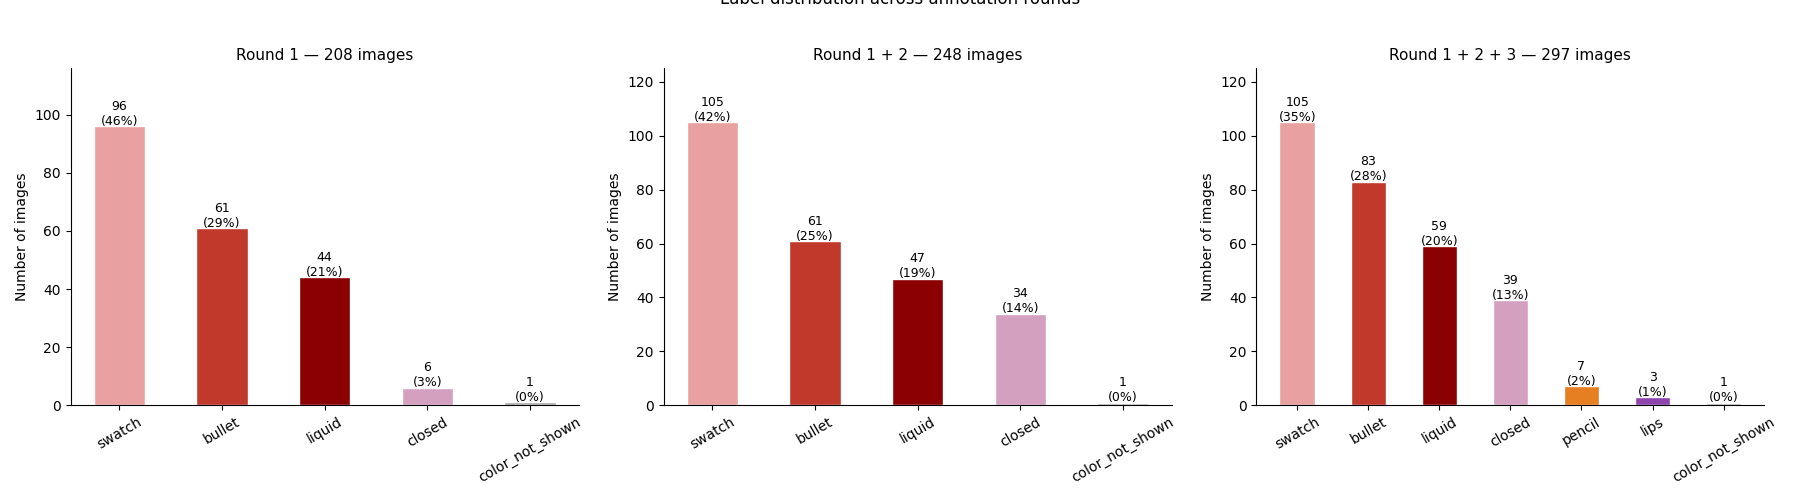

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa',
              'pencil': '#e67e22', 'lips': '#8e44ad'}

for ax, df, title in [
    (ax1, annotations,          'Round 1 — 208 images'),
    (ax2, annotations_r2,       'Round 1 + 2 — 248 images'),
    (ax3, annotations_combined, 'Round 1 + 2 + 3 — 297 images'),
]:
    counts = df['label'].value_counts()
    bar_colors = [colors_map.get(l, '#999') for l in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Number of images')
    for i, (label, val) in enumerate(counts.items()):
        ax.text(i, val + 0.5, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, counts.max() + 20)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Label distribution across annotation rounds', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution_combined.png', dpi=150, bbox_inches='tight')
plt.show()

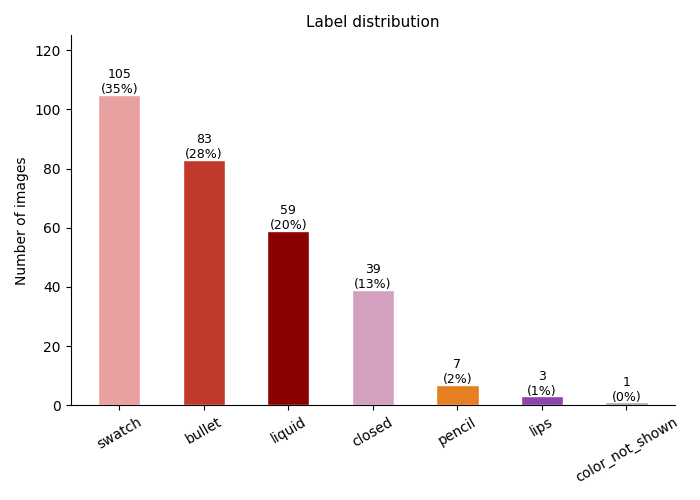

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = annotations_combined['label'].value_counts()
bar_colors = [colors_map.get(l, '#999') for l in counts.index]
ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title('Label distribution', fontsize=11)
ax.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.5, f'{val}\n({val/len(annotations_combined)*100:.0f}%)', ha='center', fontsize=9)
ax.set_ylim(0, counts.max() + 20)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()